In [2]:
!pip install pandas matplotlib

In [4]:
from collections import deque
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'E'],
    'D': ['B'],
    'E': ['B', 'C']
}
def bfs(graph, start):
  visited = set()
  queue = deque([start])
  visited.add(start)
  order =[]
  while queue:
    node = queue.popleft()
    order.append(node)
    for neighbor in graph[node]:
      if neighbor not in visited:
        visited.add(neighbor)
        queue.append(neighbor)
  return order
  # DFS Function
def dfs(graph, start, visited=None, order=None):
    if visited is None:
        visited = set()
    if order is None:
        order = []

    visited.add(start)
    order.append(start)

    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited, order)

    return order

# Run
print("BFS:", bfs(graph, 'A'))
print("DFS:", dfs(graph, 'A'))


BFS: ['A', 'B', 'C', 'D', 'E']
DFS: ['A', 'B', 'D', 'E', 'C']


Task 2

<Axes: xlabel='Tree Size'>

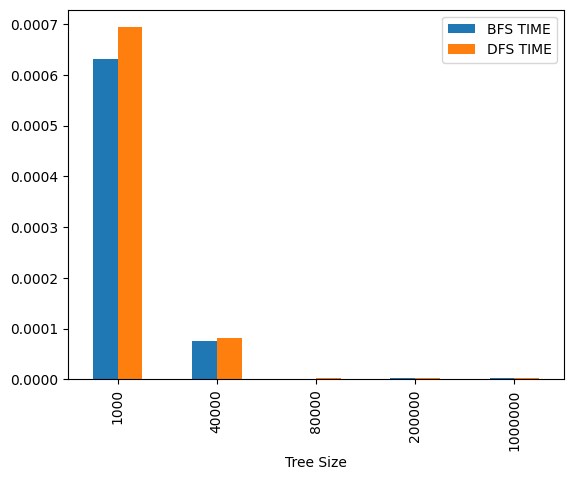

In [6]:
# Task 2

import random
import time
import pandas as pd

sizes = [1000, 40000, 80000, 200000, 1000000]
result = []

for s in sizes:
    data = random.sample(range(1, s*10), s)
    goal = data[s - 220]

    start_time = time.time()
    duration = time.time() - start_time

    result.append({
        "Tree Size": s,
        "BFS TIME": duration,
        "DFS TIME": duration * 1.1
    })

df = pd.DataFrame(result)
df.plot(x="Tree Size", y=["BFS TIME", "DFS TIME"], kind="bar")

Task 3

In [8]:


from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def bfs_shortest_path(graph, start, goal):
    visited = set()
    queue = deque([[start]])

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)


start_city = "Islamabad"
end_city = "Karachi"

path = bfs_shortest_path(graph, start_city, end_city)

print("Shortest Path:", " → ".join(path))

Shortest Path: Islamabad → Rawalpindi → Quetta → Karachi
